# 메시지 삭제

그래프의 일반적인 상태 중 하나는 메시지 목록입니다. 일반적으로 해당 상태에 메시지를 추가만 합니다. 하지만 때로는 **메시지를 제거** 해야 할 수도 있습니다. 

이를 위해 `RemoveMessage` 수정자를 사용할 수 있습니다. 그리고, `RemoveMessage` 수정자는 `reducer` 키를 가진다는 것입니다. 

기본 `MessagesState`는 messages 키를 가지고 있으며, 해당 키의 reducer는 이러한 `RemoveMessage` 수정자를 허용합니다.

이 reducer는 `RemoveMessage`를 사용하여 키에서 메시지를 삭제합니다.

> 참고 문서: [LangGraph Persistence](https://langchain-ai.github.io/langgraph/concepts/persistence/)

## 환경 설정

먼저 메시지를 사용하는 간단한 그래프를 구축해보겠습니다. 이 튜토리얼에서는 `MessagesState`를 사용합니다. `MessagesState`는 LangGraph에서 제공하는 기본 상태 타입으로, `messages` 키와 `add_messages` reducer가 미리 정의되어 있어 `RemoveMessage` 수정자를 바로 사용할 수 있습니다.

아래 코드에서는 환경 변수와 LangSmith 추적을 설정합니다.

In [1]:
# API 키를 환경변수로 관리하기 위한 설정 파일
from dotenv import load_dotenv

# API 키 정보 로드
load_dotenv(override=True)

True

In [2]:
# LangSmith 추적을 설정합니다. https://smith.langchain.com
from langchain_teddynote import logging

# 프로젝트 이름을 입력합니다.
logging.langsmith("LangGraph-V1-Tutorial")

LangSmith 추적을 시작합니다.
[프로젝트명]
LangGraph-V1-Tutorial


## 기본 LangGraph 구축

`RemoveMessage` 수정자를 테스트하기 위한 기본 에이전트 그래프를 구축합니다. 이 그래프는 검색 도구를 사용하는 간단한 에이전트로, `MemorySaver` 체크포인터를 통해 대화 기록을 저장합니다. 메시지가 누적되면서 삭제 기능을 테스트할 수 있습니다.

아래 코드에서는 검색 도구, LLM 모델, 그리고 StateGraph를 정의합니다.

In [3]:
from typing import Literal

from langchain_core.tools import tool
from langchain.chat_models import init_chat_model
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import MessagesState, StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

# 체크포인트 저장을 위한 메모리 객체 초기화
memory = MemorySaver()


# 웹 검색 기능을 모방하는 도구 함수 정의
@tool
def search(query: str):
    """Call to surf on the web."""
    return "웹 검색 결과: LangGraph 한글 튜토리얼은 https://wikidocs.net/233785 에서 확인할 수 있습니다."


# 도구 목록 생성 및 도구 노드 초기화
tools = [search]
tool_node = ToolNode(tools)

# LLM 초기화 (OpenAI 키 사용 시 gpt-5.2, gpt-4.1-mini 등으로 변경)
model = init_chat_model("claude-sonnet-4-5")
bound_model = model.bind_tools(tools)


# # 대화 상태에 따른 다음 실행 노드 결정 함수
def should_continue(state: MessagesState):
    last_message = state["messages"][-1]
    if not last_message.tool_calls:
        return END
    return "tool"


# LLM 모델 호출 및 응답 처리 함수
def call_model(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": response}


# 상태 기반 워크플로우 그래프 초기화
workflow = StateGraph(MessagesState)

# 에이전트와 액션 노드 추가
workflow.add_node("agent", call_model)
workflow.add_node("tool", tool_node)

# 시작점을 에이전트 노드로 설정
workflow.add_edge(START, "agent")

# 조건부 엣지 설정: 에이전트 노드 이후의 실행 흐름 정의
workflow.add_conditional_edges("agent", should_continue, {"tool": "tool", END: END})

# 도구 실행 후 에이전트로 돌아가는 엣지 추가
workflow.add_edge("tool", "agent")

# 체크포인터가 포함된 최종 실행 가능한 워크플로우 컴파일
app = workflow.compile(checkpointer=memory)

### 그래프 시각화

컴파일된 그래프의 구조를 시각화합니다. `agent` 노드에서 도구 호출 여부에 따라 `tool` 노드로 분기하거나 종료되는 흐름을 확인할 수 있습니다.

아래 코드는 그래프를 시각화합니다.

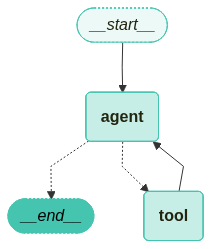

In [4]:
from langchain_teddynote.graphs import visualize_graph

visualize_graph(app)

In [5]:
from langchain_core.messages import HumanMessage

# 스레드 ID가 1인 기본 설정 객체 초기화
config = {"configurable": {"thread_id": "1"}}

# 1번째 질문 수행
input_message = HumanMessage(
    content="안녕하세요! 제 이름은 Teddy입니다. 잘 부탁드립니다."
)

# 스트림 모드로 메시지 처리 및 응답 출력, 마지막 메시지의 상세 정보 표시
for event in app.stream({"messages": [input_message]}, config, stream_mode="values"):
    event["messages"][-1].pretty_print()

================================ Human Message =================================

안녕하세요! 제 이름은 Teddy입니다. 잘 부탁드립니다.
================================== Ai Message ==================================

안녕하세요, Teddy님! 만나서 반갑습니다. 😊

저는 Claude이고, 여러분의 질문에 답하고 대화를 나누는 AI 어시스턴트입니다. 

궁금하신 점이나 도움이 필요하신 일이 있으시면 편하게 말씀해 주세요. 잘 부탁드립니다!


In [6]:
# 후속 질문 수행
input_message = HumanMessage(content="내 이름이 뭐라고요?")

# 스트림 모드로 두 번째 메시지 처리 및 응답 출력
for event in app.stream({"messages": [input_message]}, config, stream_mode="values"):
    event["messages"][-1].pretty_print()

================================ Human Message =================================

내 이름이 뭐라고요?
================================== Ai Message ==================================

당신의 이름은 Teddy라고 하셨습니다! 😊


In [7]:
# 단계별 상태 확인
messages = app.get_state(config).values["messages"]
for message in messages:
    message.pretty_print()

================================ Human Message =================================

안녕하세요! 제 이름은 Teddy입니다. 잘 부탁드립니다.
================================== Ai Message ==================================

안녕하세요, Teddy님! 만나서 반갑습니다. 😊

저는 Claude이고, 여러분의 질문에 답하고 대화를 나누는 AI 어시스턴트입니다. 

궁금하신 점이나 도움이 필요하신 일이 있으시면 편하게 말씀해 주세요. 잘 부탁드립니다!
================================ Human Message =================================

내 이름이 뭐라고요?
================================== Ai Message ==================================

당신의 이름은 Teddy라고 하셨습니다! 😊


## RemoveMessage 수정자를 사용한 메시지 삭제

`RemoveMessage`는 LangGraph에서 제공하는 특수 수정자로, 메시지 목록에서 특정 메시지를 삭제할 때 사용합니다. `update_state()` 메서드와 함께 사용하면 그래프 상태에서 원하는 메시지를 선택적으로 제거할 수 있습니다.

먼저 현재 스레드의 상태를 확인하여 저장된 메시지들을 살펴보겠습니다.

In [8]:
# 앱 상태에서 메시지 목록 추출 및 저장
messages = app.get_state(config).values["messages"]
# 메시지 목록 반환
for message in messages:
    message.pretty_print()

================================ Human Message =================================

안녕하세요! 제 이름은 Teddy입니다. 잘 부탁드립니다.
================================== Ai Message ==================================

안녕하세요, Teddy님! 만나서 반갑습니다. 😊

저는 Claude이고, 여러분의 질문에 답하고 대화를 나누는 AI 어시스턴트입니다. 

궁금하신 점이나 도움이 필요하신 일이 있으시면 편하게 말씀해 주세요. 잘 부탁드립니다!
================================ Human Message =================================

내 이름이 뭐라고요?
================================== Ai Message ==================================

당신의 이름은 Teddy라고 하셨습니다! 😊


### 수동으로 메시지 삭제하기

`update_state()` 메서드를 호출하고 `RemoveMessage`에 삭제할 메시지의 `id`를 전달하면 해당 메시지가 상태에서 제거됩니다. 각 메시지는 고유한 `id` 속성을 가지고 있어 정확하게 삭제 대상을 지정할 수 있습니다.

아래 코드에서는 첫 번째 메시지를 삭제합니다.

In [9]:
from langchain_core.messages import RemoveMessage

# 메시지 배열의 첫 번째 메시지를 ID 기반으로 제거하고 앱 상태 업데이트
app.update_state(config, {"messages": RemoveMessage(id=messages[0].id)})

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f1118af-5554-62ca-8005-99c0cbccd914'}}

### 삭제 결과 확인

다시 메시지 목록을 조회하면 첫 번째 메시지(사용자의 인사말)가 삭제되어 더 이상 목록에 나타나지 않는 것을 확인할 수 있습니다.

아래 코드에서는 삭제 후 남은 메시지들을 출력합니다.

In [10]:
# 앱 상태에서 메시지 목록 추출 및 저장된 대화 내역 조회
messages = app.get_state(config).values["messages"]
for message in messages:
    message.pretty_print()

================================== Ai Message ==================================

안녕하세요, Teddy님! 만나서 반갑습니다. 😊

저는 Claude이고, 여러분의 질문에 답하고 대화를 나누는 AI 어시스턴트입니다. 

궁금하신 점이나 도움이 필요하신 일이 있으시면 편하게 말씀해 주세요. 잘 부탁드립니다!
================================ Human Message =================================

내 이름이 뭐라고요?
================================== Ai Message ==================================

당신의 이름은 Teddy라고 하셨습니다! 😊


## 그래프 내부에서 동적으로 메시지 삭제

수동 삭제 외에도 그래프 실행 중에 자동으로 오래된 메시지를 삭제하는 로직을 구현할 수 있습니다. 이는 대화가 길어질 때 컨텍스트 윈도우를 관리하거나 토큰 비용을 절약하는 데 유용합니다.

아래 예시에서는 그래프 실행이 종료될 때 최근 3개 메시지만 유지하고 나머지는 자동으로 삭제하는 `delete_messages` 노드를 추가합니다.

In [11]:
from langchain_core.messages import RemoveMessage
from langgraph.graph import END


# 메시지 개수가 3개 초과 시 오래된 메시지 삭제 및 최신 메시지만 유지
def delete_messages(state):
    messages = state["messages"]
    if len(messages) > 3:
        return {"messages": [RemoveMessage(id=m.id) for m in messages[:-3]]}


# 메시지 상태에 따른 다음 실행 노드 결정 로직
def should_continue(state: MessagesState) -> Literal["action", "delete_messages"]:
    """Return the next node to execute."""
    last_message = state["messages"][-1]
    # 함수 호출이 없는 경우 메시지 삭제 함수 실행
    if not last_message.tool_calls:
        return "delete_messages"
    # 함수 호출이 있는 경우 액션 실행
    return "action"


# 메시지 상태 기반 워크플로우 그래프 정의
workflow = StateGraph(MessagesState)

# 에이전트와 액션 노드 추가
workflow.add_node("agent", call_model)
workflow.add_node("action", tool_node)

# 메시지 삭제 노드 추가
workflow.add_node(delete_messages)

# 시작 노드에서 에이전트 노드로 연결
workflow.add_edge(START, "agent")

# 조건부 엣지 추가를 통한 노드 간 흐름 제어
workflow.add_conditional_edges(
    "agent",
    should_continue,
)

# 액션 노드에서 에이전트 노드로 연결
workflow.add_edge("action", "agent")

# 메시지 삭제 노드에서 종료 노드로 연결
workflow.add_edge("delete_messages", END)

# 메모리 체크포인터를 사용하여 워크플로우 컴파일
app = workflow.compile(checkpointer=memory)

### 수정된 그래프 시각화

수정된 그래프에는 `delete_messages` 노드가 추가되었습니다. 에이전트가 도구 호출 없이 응답을 완료하면 `delete_messages` 노드를 거쳐 종료됩니다.

아래 코드는 수정된 그래프를 시각화합니다.

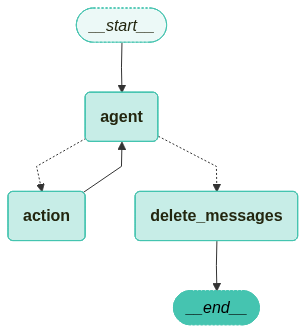

In [12]:
from langchain_teddynote.graphs import visualize_graph

visualize_graph(app)

### 동적 삭제 테스트

이제 그래프를 두 번 호출하여 메시지가 누적되는지, 그리고 오래된 메시지가 자동으로 삭제되는지 확인해보겠습니다. 각 호출 후 상태에는 최신 3개의 메시지만 유지됩니다.

아래 코드에서는 연속으로 두 번 대화를 수행합니다.

In [13]:
# LangChain 메시지 처리를 위한 HumanMessage 클래스 임포트
from langchain_core.messages import HumanMessage

# 스레드 ID가 포함된 설정 객체 초기화
config = {"configurable": {"thread_id": "2"}}

# 1번째 질문 수행
input_message = HumanMessage(
    content="안녕하세요! 제 이름은 Teddy입니다. 잘 부탁드립니다."
)
for event in app.stream({"messages": [input_message]}, config, stream_mode="values"):
    print([(message.type, message.content) for message in event["messages"]])

[('human', '안녕하세요! 제 이름은 Teddy입니다. 잘 부탁드립니다.')]
[('human', '안녕하세요! 제 이름은 Teddy입니다. 잘 부탁드립니다.'), ('ai', '안녕하세요, Teddy님! 반갑습니다. 😊\n\n저는 Claude이고, 어떤 질문이나 대화든 도움을 드리기 위해 여기 있습니다. 편하게 이야기 나눠요. 오늘 무엇을 도와드릴까요?')]


In [14]:
# 2번째 질문 수행
input_message = HumanMessage(content="내 이름이 뭐라고요?")

for event in app.stream({"messages": [input_message]}, config, stream_mode="values"):
    print([(message.type, message.content) for message in event["messages"]])

[('human', '안녕하세요! 제 이름은 Teddy입니다. 잘 부탁드립니다.'), ('ai', '안녕하세요, Teddy님! 반갑습니다. 😊\n\n저는 Claude이고, 어떤 질문이나 대화든 도움을 드리기 위해 여기 있습니다. 편하게 이야기 나눠요. 오늘 무엇을 도와드릴까요?'), ('human', '내 이름이 뭐라고요?')]
[('human', '안녕하세요! 제 이름은 Teddy입니다. 잘 부탁드립니다.'), ('ai', '안녕하세요, Teddy님! 반갑습니다. 😊\n\n저는 Claude이고, 어떤 질문이나 대화든 도움을 드리기 위해 여기 있습니다. 편하게 이야기 나눠요. 오늘 무엇을 도와드릴까요?'), ('human', '내 이름이 뭐라고요?'), ('ai', '당신의 이름은 Teddy라고 하셨습니다! 😊')]
[('ai', '안녕하세요, Teddy님! 반갑습니다. 😊\n\n저는 Claude이고, 어떤 질문이나 대화든 도움을 드리기 위해 여기 있습니다. 편하게 이야기 나눠요. 오늘 무엇을 도와드릴까요?'), ('human', '내 이름이 뭐라고요?'), ('ai', '당신의 이름은 Teddy라고 하셨습니다! 😊')]


### 최종 상태 확인

최종 상태를 확인하면 메시지가 3개만 남아있는 것을 볼 수 있습니다. `delete_messages` 노드가 실행될 때마다 오래된 메시지들이 자동으로 제거되어 항상 최신 대화 내용만 유지됩니다.

아래 코드에서는 최종 메시지 목록을 출력합니다.

In [15]:
# 앱 상태에서 메시지 목록 추출 및 저장
messages = app.get_state(config).values["messages"]
# 메시지 목록 반환
for message in messages:
    message.pretty_print()

================================== Ai Message ==================================

안녕하세요, Teddy님! 반갑습니다. 😊

저는 Claude이고, 어떤 질문이나 대화든 도움을 드리기 위해 여기 있습니다. 편하게 이야기 나눠요. 오늘 무엇을 도와드릴까요?
================================ Human Message =================================

내 이름이 뭐라고요?
================================== Ai Message ==================================

당신의 이름은 Teddy라고 하셨습니다! 😊
